In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import muspan as ms
from itertools import zip_longest
from typing import List, Tuple, Optional
import math
from functools import partial
import seaborn as sns
from scipy import stats
import pathlib

In [2]:
domain = ms.io.load_domain('../domains_with_mets/Sample_28d_2_2.muspan')

MuSpAn domain loaded successfully. Domain summary:
Domain name: AKPT_Liver_Mets_28d_2_Region_2
Number of objects: 324576
Collections: ['Cell boundaries', 'Cell centres', 'Detailed Met Annotations', 'Cell Boundaries in Met 1', 'Cell Centres in Met 1', 'Metastasis 1', 'Cell Boundaries in Met 2', 'Cell Centres in Met 2', 'Metastasis 2', 'Cell Boundaries in Met 3', 'Cell Centres in Met 3', 'Metastasis 3', 'Cell Boundaries in Met 4', 'Cell Centres in Met 4', 'Metastasis 4', 'Cell Boundaries in Met 5', 'Cell Centres in Met 5', 'Metastasis 5', 'Cell Boundaries in Met 6', 'Cell Centres in Met 6', 'Metastasis 6', 'Cell Boundaries in Met 7', 'Cell Centres in Met 7', 'Metastasis 7']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Cluster ID', 'Nucleus Area', 'Transcript Counts: 1700019D03Rik', 'Transcript Counts: Abcc8', 'Transcript Counts: Acta2', 'Transcript Counts: Acvr1b', 'Transcript Counts: Acvr2a', 'Transcript Counts: Adgra2', 'Transcript Counts: Adgre1', 'Transcript Counts: Adh1', 

75
5.200954161562762


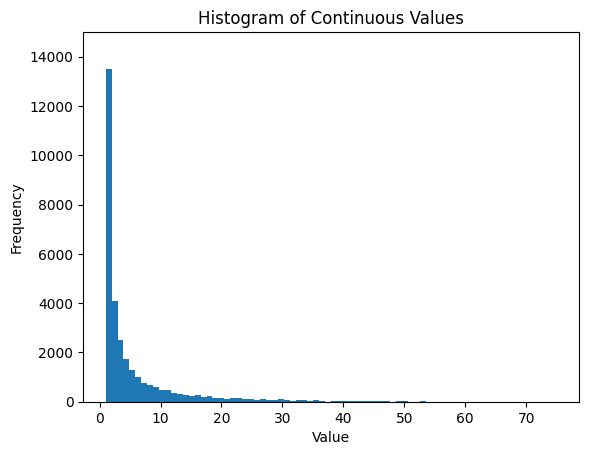

In [45]:
import matplotlib.pyplot as plt
Clec4f = domain.labels['Transcript Counts: Clec4f']['labels']
Clec4f = [x for x in Clec4f if x != 0]

# Example list of continuous v
# Create histogram
print(np.max(Clec4f))
print(np.mean(Clec4f))
plt.hist(Clec4f, bins=76)  # adjust bins as needed

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Continuous Values")

# Show plot
plt.ylim([0,15000])
plt.show()


53
1.0
1.0
2.0


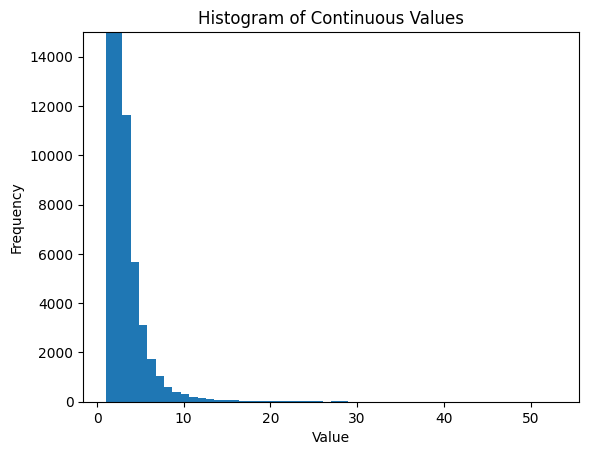

In [14]:
import matplotlib.pyplot as plt
CD14 = domain.labels['Transcript Counts: Cd14']['labels']
CD14 = [x for x in CD14 if x != 0]

# Example list of continuous v
# Create histogram
print(np.max(CD14))
print(np.percentile(CD14, 25))
print(np.median(CD14))
print(np.percentile(CD14, 75))
plt.hist(CD14, bins=54)  # adjust bins as needed

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Continuous Values")

# Show plot
plt.ylim([0,15000])
plt.show()


28
1.0


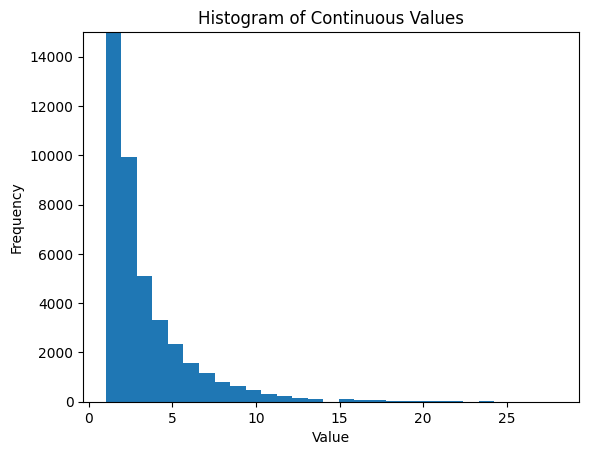

In [ ]:
import matplotlib.pyplot as plt
CCR2 = domain.labels['Transcript Counts: Ccr2']['labels']
CCR2 = [x for x in CCR2 if x != 0]
# Example list of continuous v
# Create histogram
print(np.max(CCR2))
# print(np.percentile(CCR2,25))
print(np.median(CCR2))
# print(np.percentile(CCR2,75))
plt.hist(CCR2, bins=29)  # adjust bins as needed

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Continuous Values")

# Show plot
plt.ylim([0,15000])
plt.show()


In [3]:
list_of_domains = [domain]
met_nos = [7]

In [ ]:
'Infiltrating Macrophages (TAMs)'
'Kupffer cells'

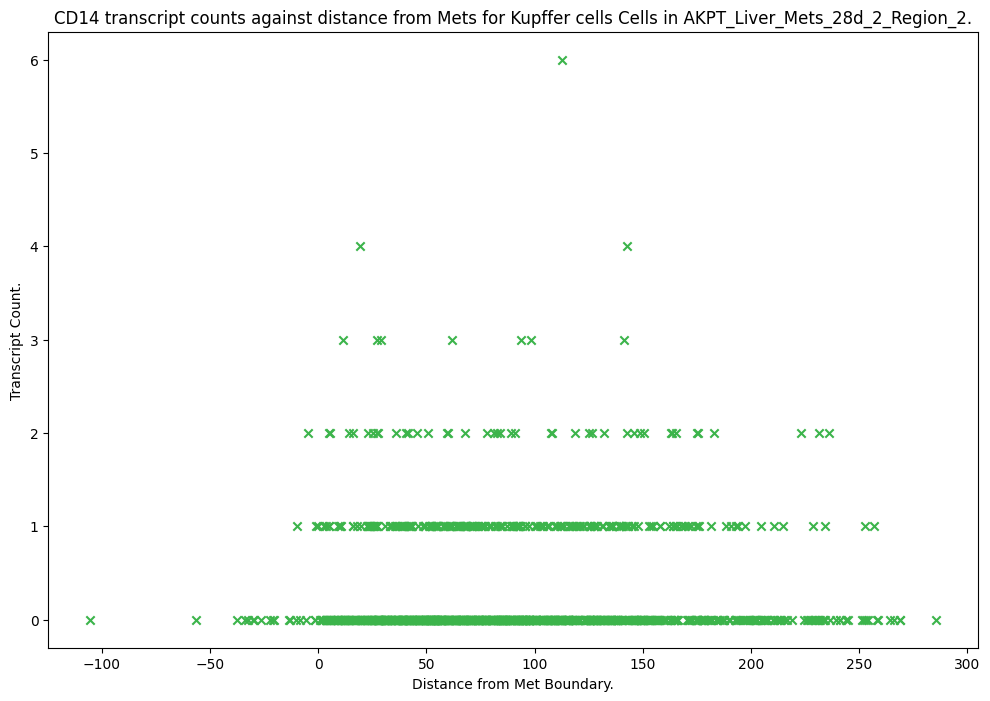

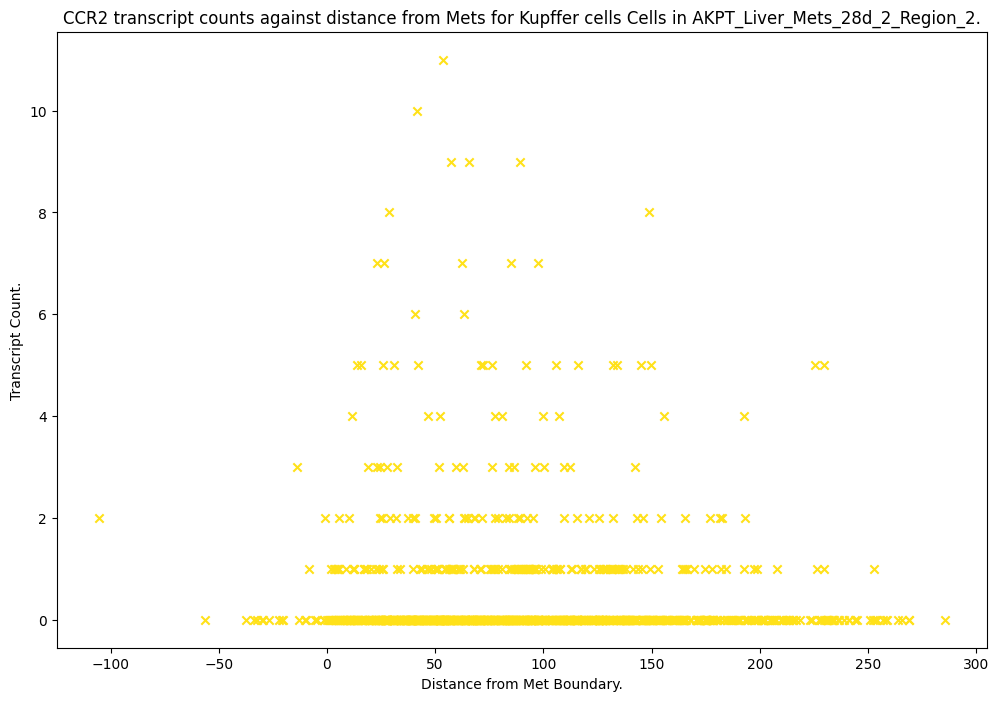

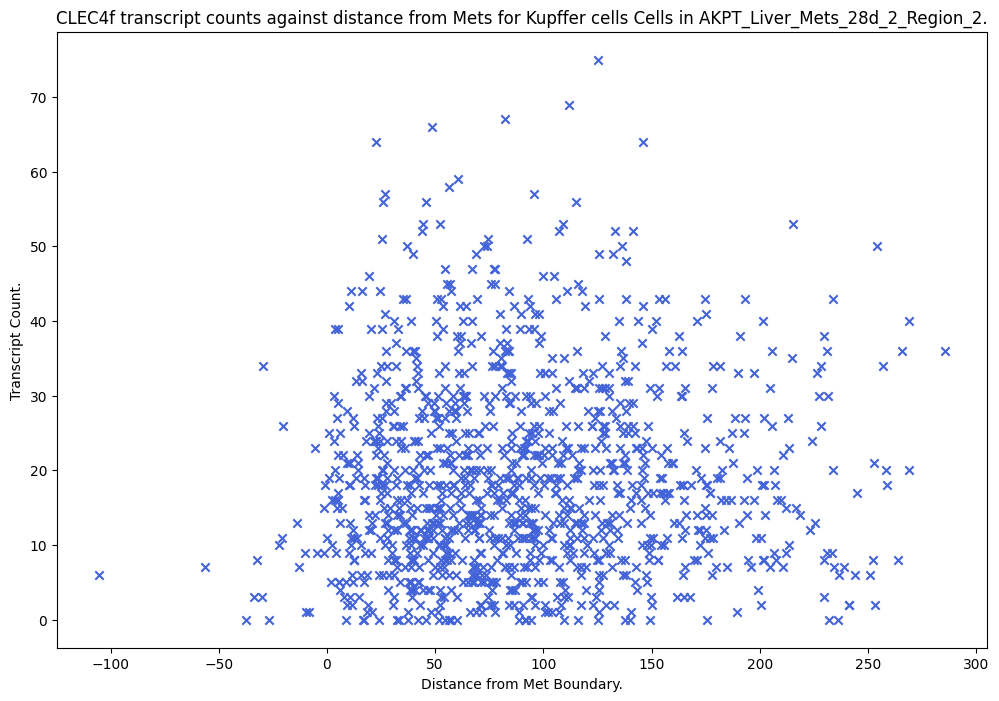

In [47]:
# specify cell type of interest
celltype = 'Kupffer cells'
label_name = 'Detailed celltype (liver)'
colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
list_of_axes = []
list_of_figs = []
list_of_max_met_dists = []
list_of_max_out_dists = []
all_met_distances = []
all_out_distances = []
all_regional_max_met_dists = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[dom]
    one_domain_met_distances = []
    one_domain_out_distances = []
    for region_no in range(met_no):
        met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
        one_domain_met_distances.append(met_distances)
    out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
    # one_domain_out_distances.append(out_distances)
    all_out_distances.append(out_distances)
    all_met_distances.append(one_domain_met_distances)

for i in range(3):
    fig, axes = plt.subplots(1, 1, figsize=(12, 8))
    axes.set_title('Transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')
    axes.set_xlabel('Distance from Met Boundary.')
    axes.set_ylabel('Transcript Count.')
    list_of_axes.append(axes)
    list_of_figs.append(fig)
    
for dom in range(len(list_of_domains)):
    # figures
    domain = list_of_domains[dom]
    met_no = met_nos[dom]
    # met distances
    max_met_dist=0
    regional_max_met_dists = []
    shape_cell_distances = all_met_distances[dom]
    for region_no in range(met_no):
        distances = shape_cell_distances[region_no][1]
        regional_max_met_dists.append(np.max(distances))
        if np.max(distances) > max_met_dist:
            max_met_dist = np.max(distances)
    list_of_max_met_dists.append(max_met_dist)
    all_regional_max_met_dists.append(regional_max_met_dists)

    # out distances
    shape_cell_distances_out = all_out_distances[dom]
    distances_out = [sublist[1] for sublist in shape_cell_distances_out]
    list_of_max_out_dists.append(np.max(distances_out))


all_domains_met_distances_subregions = []
all_domains_met_distances_joined = []
for dom in range(len(list_of_domains)):
    Cd14 = domain.labels['Transcript Counts: Cd14']['labels']
    Ccr2 = domain.labels['Transcript Counts: Ccr2']['labels']
    Clec4f = domain.labels['Transcript Counts: Clec4f']['labels']
    ids = domain.labels['Transcript Counts: Clec4f']['objects']
    all_relevant_distances = []
    all_relevant_distances = []
    all_relevant_distances = []
    all_relevant_distances = []
    overall_x_min = 0

    domain = list_of_domains[dom]
    met_no = met_nos[dom]
    query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
    ### cell_type : collection or label
        # the collection or label of the objects that you would like to compute the shaped cross-pcf metric for - soon you will be able to calculate
        # for several cell types and return each one separately - currently need to set cell type to population, this is just here for future purposes
    all_normalised_distances = []
    all_Cd14_scores = []
    all_Ccr2_scores = []
    all_Clec4f_scores = []
    # loop through each subshape
    all_kdes = []
    all_regions_distances = []
    for region_no in range(met_no):
        specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

        shape_cell_distances = all_met_distances[dom][region_no]
        distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
        relevant_dist_ids = [x for x in shape_cell_distances[0] if x in specific_cell_IDs]
        relevant_ids = [i for i in range(len(Cd14)) if ids[i] in relevant_dist_ids]
        Cd14_scores = [Cd14[i] for i in relevant_ids]
        Ccr2_scores = [Ccr2[i] for i in relevant_ids]
        Clec4f_scores = [Clec4f[i] for i in relevant_ids]
        # normalised_distances = distances/all_regional_max_met_dists[dom][region_no]
        if len(distances) > 1:
            x_max = np.max(distances)
            kde = stats.gaussian_kde(distances)
            x_eval = np.linspace(0, x_max, num=200)
            array_temp = np.array(x_eval)*-1
            x = list(array_temp)
            x_min = -x_max
            if x_min < overall_x_min:
                overall_x_min = x_min
            distances_new = [-x for x in distances]
            all_relevant_distances.extend(distances_new)
            all_Cd14_scores.extend(Cd14_scores)
            all_Ccr2_scores.extend(Ccr2_scores)
            all_Clec4f_scores.extend(Clec4f_scores)


    
    specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

    shape_cell_distances = all_out_distances[dom]
    distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
    relevant_dist_ids = [x for x in shape_cell_distances[0] if x in specific_cell_IDs]
    relevant_ids = [i for i in range(len(Cd14)) if ids[i] in relevant_dist_ids]
    Cd14_scores = [Cd14[i] for i in relevant_ids]
    Ccr2_scores = [Ccr2[i] for i in relevant_ids]
    Clec4f_scores = [Clec4f[i] for i in relevant_ids]
    
    # normalised_distances = [a/(a+b) for a,b in zip(distances, distances1)]
    if len(distances) > 1:
        x_max = np.max(distances)
        all_relevant_distances.extend(distances)
        all_Cd14_scores.extend(Cd14_scores)
        all_Ccr2_scores.extend(Ccr2_scores)
        all_Clec4f_scores.extend(Clec4f_scores)
    if len(all_relevant_distances) > 1:
        kde = stats.gaussian_kde(all_relevant_distances)
        x_eval = np.linspace(overall_x_min-5, x_max+5, num=2)
        # list_of_axes[dom].plot(x_eval, kde(x_eval), color = colours[0],label=celltype+'Density')
        
        list_of_axes[dom].scatter(all_relevant_distances, all_Cd14_scores, marker = 'x', color = colours[1],label='CD14')
        # b, a = np.polyfit(all_relevant_distances, all_Cd14_scores, deg=1)
        # # Create sequence of 100 numbers from 0 to 100
        # x_eval = np.linspace(overall_x_min-5, x_max+5, num=2)
        # # Plot regression line
        # list_of_axes[dom].plot(x_eval, a + b * x_eval, color=colours[1], lw=2.5)
        list_of_axes[dom].set_title('CD14 transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')
        list_of_axes[1].scatter(all_relevant_distances, all_Ccr2_scores, marker = 'x', color = colours[2],label='CCR2')

        # b, a = np.polyfit(all_relevant_distances, all_Ccr2_scores, deg=1)
        # # Create sequence of 100 numbers from 0 to 100
        # x_eval = np.linspace(overall_x_min-5, x_max+5, num=2)
        # # Plot regression line
        # list_of_axes[1].plot(x_eval, a + b * x_eval, color=colours[2], lw=2.5)
        list_of_axes[1].set_title('CCR2 transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')

        list_of_axes[2].scatter(all_relevant_distances, all_Clec4f_scores, marker = 'x', color = colours[3],label='CLEC4f')
        list_of_axes[2].set_title('CLEC4f transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')

        # list_of_axes[2].hist2d(all_relevant_distances, all_Clec4f_scores, bins = 100, color = colours[3],label='CLEC4f')

        # b, a = np.polyfit(all_relevant_distances, all_Clec4f_scores, deg=1)
        # # Create sequence of 100 numbers from 0 to 100
        # x_eval = np.linspace(overall_x_min-5, x_max+5, num=2)
        # # Plot regression line
        # list_of_axes[2].plot(x_eval, a + b * x_eval, color=colours[3], lw=2.5)


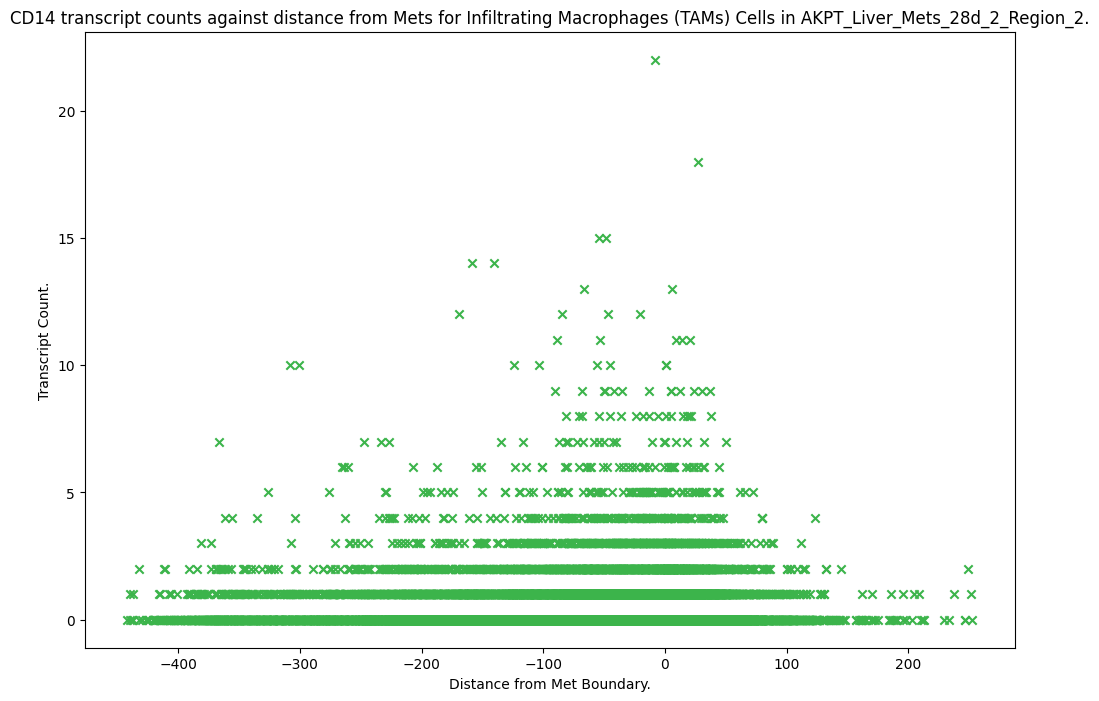

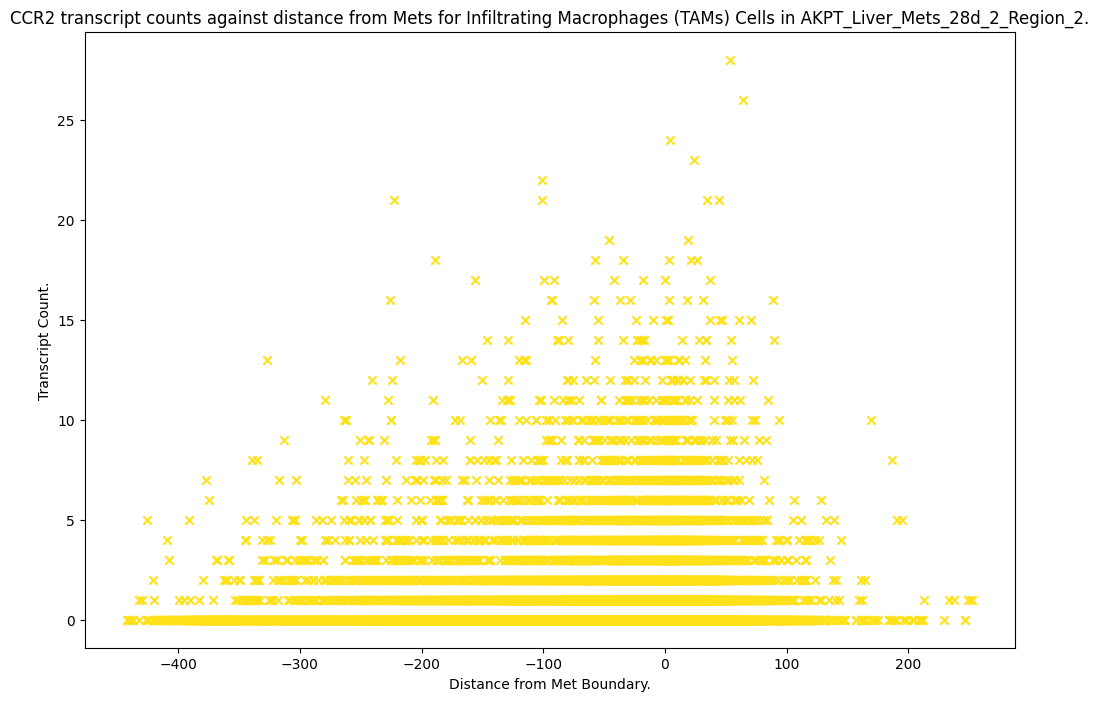

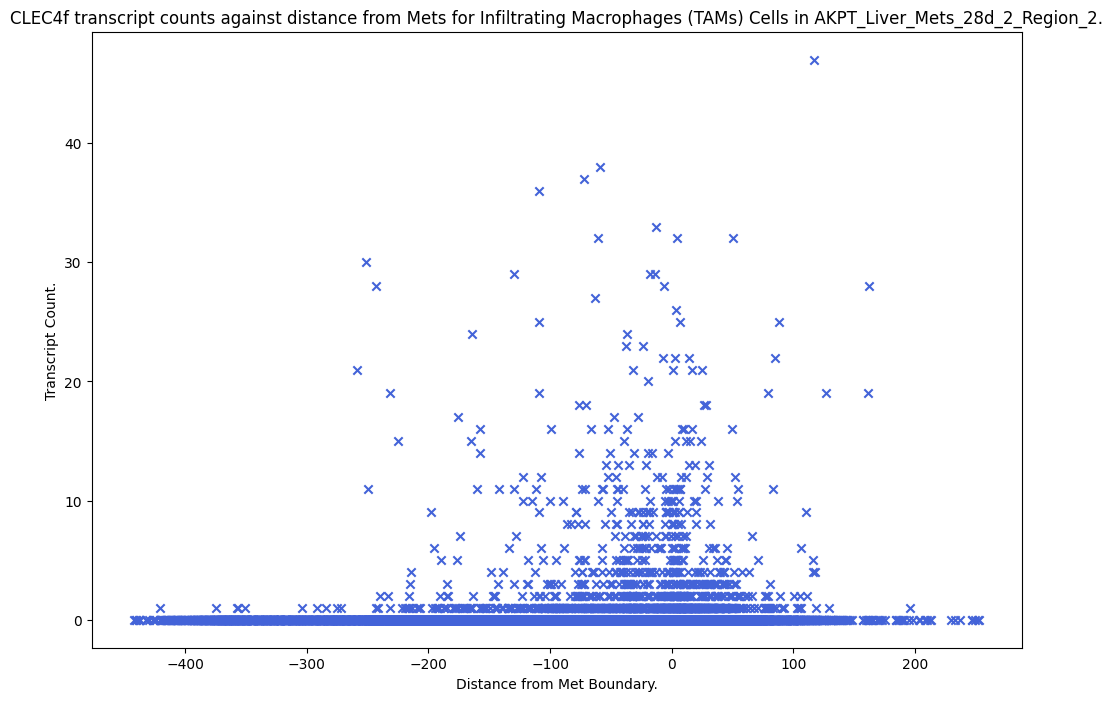

In [48]:
# specify cell type of interest
celltype = 'Infiltrating Macrophages (TAMs)'
label_name = 'Detailed celltype (liver)'
colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
list_of_axes = []
list_of_figs = []
list_of_max_met_dists = []
list_of_max_out_dists = []
all_met_distances = []
all_out_distances = []
all_regional_max_met_dists = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[dom]
    one_domain_met_distances = []
    one_domain_out_distances = []
    for region_no in range(met_no):
        met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
        one_domain_met_distances.append(met_distances)
    out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
    # one_domain_out_distances.append(out_distances)
    all_out_distances.append(out_distances)
    all_met_distances.append(one_domain_met_distances)

for i in range(3):
    fig, axes = plt.subplots(1, 1, figsize=(12, 8))
    axes.set_title('Transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')
    axes.set_xlabel('Distance from Met Boundary.')
    axes.set_ylabel('Transcript Count.')
    list_of_axes.append(axes)
    list_of_figs.append(fig)
    
for dom in range(len(list_of_domains)):
    # figures
    domain = list_of_domains[dom]
    met_no = met_nos[dom]
    # met distances
    max_met_dist=0
    regional_max_met_dists = []
    shape_cell_distances = all_met_distances[dom]
    for region_no in range(met_no):
        distances = shape_cell_distances[region_no][1]
        regional_max_met_dists.append(np.max(distances))
        if np.max(distances) > max_met_dist:
            max_met_dist = np.max(distances)
    list_of_max_met_dists.append(max_met_dist)
    all_regional_max_met_dists.append(regional_max_met_dists)

    # out distances
    shape_cell_distances_out = all_out_distances[dom]
    distances_out = [sublist[1] for sublist in shape_cell_distances_out]
    list_of_max_out_dists.append(np.max(distances_out))


all_domains_met_distances_subregions = []
all_domains_met_distances_joined = []
for dom in range(len(list_of_domains)):
    Cd14 = domain.labels['Transcript Counts: Cd14']['labels']
    Ccr2 = domain.labels['Transcript Counts: Ccr2']['labels']
    Clec4f = domain.labels['Transcript Counts: Clec4f']['labels']
    ids = domain.labels['Transcript Counts: Clec4f']['objects']
    all_relevant_distances = []
    all_relevant_distances = []
    all_relevant_distances = []
    all_relevant_distances = []
    overall_x_min = 0

    domain = list_of_domains[dom]
    met_no = met_nos[dom]
    query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
    ### cell_type : collection or label
        # the collection or label of the objects that you would like to compute the shaped cross-pcf metric for - soon you will be able to calculate
        # for several cell types and return each one separately - currently need to set cell type to population, this is just here for future purposes
    all_normalised_distances = []
    all_Cd14_scores = []
    all_Ccr2_scores = []
    all_Clec4f_scores = []
    # loop through each subshape
    all_kdes = []
    all_regions_distances = []
    for region_no in range(met_no):
        specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

        shape_cell_distances = all_met_distances[dom][region_no]
        distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
        relevant_dist_ids = [x for x in shape_cell_distances[0] if x in specific_cell_IDs]
        relevant_ids = [i for i in range(len(Cd14)) if ids[i] in relevant_dist_ids]
        Cd14_scores = [Cd14[i] for i in relevant_ids]
        Ccr2_scores = [Ccr2[i] for i in relevant_ids]
        Clec4f_scores = [Clec4f[i] for i in relevant_ids]
        # normalised_distances = distances/all_regional_max_met_dists[dom][region_no]
        if len(distances) > 1:
            x_max = np.max(distances)
            kde = stats.gaussian_kde(distances)
            x_eval = np.linspace(0, x_max, num=200)
            array_temp = np.array(x_eval)*-1
            x = list(array_temp)
            x_min = -x_max
            if x_min < overall_x_min:
                overall_x_min = x_min
            distances_new = [-x for x in distances]
            all_relevant_distances.extend(distances_new)
            all_Cd14_scores.extend(Cd14_scores)
            all_Ccr2_scores.extend(Ccr2_scores)
            all_Clec4f_scores.extend(Clec4f_scores)


    
    specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

    shape_cell_distances = all_out_distances[dom]
    distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
    relevant_dist_ids = [x for x in shape_cell_distances[0] if x in specific_cell_IDs]
    relevant_ids = [i for i in range(len(Cd14)) if ids[i] in relevant_dist_ids]
    Cd14_scores = [Cd14[i] for i in relevant_ids]
    Ccr2_scores = [Ccr2[i] for i in relevant_ids]
    Clec4f_scores = [Clec4f[i] for i in relevant_ids]
    
    # normalised_distances = [a/(a+b) for a,b in zip(distances, distances1)]
    if len(distances) > 1:
        x_max = np.max(distances)
        all_relevant_distances.extend(distances)
        all_Cd14_scores.extend(Cd14_scores)
        all_Ccr2_scores.extend(Ccr2_scores)
        all_Clec4f_scores.extend(Clec4f_scores)
    if len(all_relevant_distances) > 1:
        kde = stats.gaussian_kde(all_relevant_distances)
        x_eval = np.linspace(overall_x_min-5, x_max+5, num=2)
        # list_of_axes[dom].plot(x_eval, kde(x_eval), color = colours[0],label=celltype+'Density')
        
        list_of_axes[dom].scatter(all_relevant_distances, all_Cd14_scores, marker = 'x', color = colours[1],label='CD14')
        # b, a = np.polyfit(all_relevant_distances, all_Cd14_scores, deg=1)
        # # Create sequence of 100 numbers from 0 to 100
        # x_eval = np.linspace(overall_x_min-5, x_max+5, num=2)
        # # Plot regression line
        # list_of_axes[dom].plot(x_eval, a + b * x_eval, color=colours[1], lw=2.5)
        list_of_axes[dom].set_title('CD14 transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')
        list_of_axes[1].scatter(all_relevant_distances, all_Ccr2_scores, marker = 'x', color = colours[2],label='CCR2')

        # b, a = np.polyfit(all_relevant_distances, all_Ccr2_scores, deg=1)
        # # Create sequence of 100 numbers from 0 to 100
        # x_eval = np.linspace(overall_x_min-5, x_max+5, num=2)
        # # Plot regression line
        # list_of_axes[1].plot(x_eval, a + b * x_eval, color=colours[2], lw=2.5)
        list_of_axes[1].set_title('CCR2 transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')

        list_of_axes[2].scatter(all_relevant_distances, all_Clec4f_scores, marker = 'x', color = colours[3],label='CLEC4f')
        list_of_axes[2].set_title('CLEC4f transcript counts against distance from Mets for '+celltype+' Cells in ' +str(domain.name)+'.')

